# Analisi diffusione covid19!

Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
url= 'https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv'
covid_19 = pd.read_csv(url)

uso head per vedere la qualita della tabella, cosi da poter vedere un po' com'è strutturata

In [3]:
covid_19.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


1) Si richiede di verificare le dimensioni del dataset e i relativi **Metadati!**
   qui ho fatto .shape per vedere di quante righe e colonne è formata la tabella e.info per vedere che tipo sono i dati all'interno della tabella

In [3]:
covid_19.shape

(429435, 67)

In [10]:
covid_19.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   iso_code                                    429435 non-null  object        
 1   continent                                   402910 non-null  object        
 2   location                                    429435 non-null  object        
 3   date                                        429435 non-null  datetime64[ns]
 4   total_cases                                 411804 non-null  float64       
 5   new_cases                                   410159 non-null  float64       
 6   new_cases_smoothed                          408929 non-null  float64       
 7   total_deaths                                411804 non-null  float64       
 8   new_deaths                                  410608 non-null  float64      

qui faccio un .columns per vedere i nomi delle colonne e come sono scritti

In [4]:
covid_19.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

e qui .unique per  vedere i nomi dei continenti per poi iniziare a lavorarci

In [21]:
print(covid_19['continent'].unique())

['Asia' nan 'Europe' 'Africa' 'Oceania' 'North America' 'South America']


TASK 2 Si chiede di trovare, per ogni continente: 
  a)il numero di casi fin dall'inizio della pandemia 
  b)la percentuale rispetto al totale mondiale del numero di casi


2A df['location']: Guarda solo la colonna "location".

.isin(continenti): Per ogni riga, controlla se il valore in "location" è presente nella nostra lista (es: "Europe" sì, "Italy" no, "World" no).

df[...]: Prende solo le righe dove il controllo sopra è "Vero" e mettile in un nuovo sotto-dataset chiamato df_cont.

In [5]:
continenti= ['Asia', 'Europe' ,'Africa', 'Oceania', 'North America', 'South America']
df_cont = covid_19[covid_19['location'].isin(continenti)]

casi_totali_cont = df_cont.groupby('location')['total_cases'].max()
print(casi_totali_cont)

location
Africa            13145380.0
Asia             301499099.0
Europe           252916868.0
North America    124492666.0
Oceania           15003352.0
South America     68809418.0
Name: total_cases, dtype: float64


2B df'location'] == 'World': Crea un filtro che tiene solo le righe dove la località è il mondo intero.

 total_cases' Di quelle righe, ci interessa solo la colonna dei casi totali.

.max(): Prende il valore più alto registrato (ovvero quello dell'ultimo giorno disponibile), che rappresenta il totale cumulativo mondiale ad oggi.

In [6]:
mondo_totale = covid_19[covid_19['location'] == 'World']['total_cases'].max()
percentuali = (casi_totali_cont / mondo_totale) * 100
print(percentuali)

location
Africa            1.694283
Asia             38.859648
Europe           32.597976
North America    16.045624
Oceania           1.933754
South America     8.868716
Name: total_cases, dtype: float64


In [7]:
print(percentuali.sum())

100.0


TASK 3
Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati: 
A) l'evoluzione del casi totali dall'inizio alla fine dell'anno
B) il numero di nuovi casi rispetto alla data

converto la data da object a datetime e verifico ora la quantita di righe del nuovo dataframe filtrato

In [7]:
covid_19['date'] = pd.to_datetime(covid_19['date'])

In [8]:
italy_22= covid_19[(covid_19['location'] == 'Italy') & ( covid_19 ['date'].dt.year == 2022)].copy()
print(italy_22.shape)                  

(365, 67)


In [ ]:
italy_22.head()

In [ ]:
italy_22= italy_22[italy_22['new_cases'] > 0]
italy_22.head()

RISPOSTA TASK 3 
A) Creo un grafico a linee che mostra l'andamento dei contagi in Italia per tutto il 2022, usando il colore rosso e uno spessore della linea ben visibile.Serve a visualizzare la tendenza (il trend) dei casi; essendo dati cumulativi, la linea salirà sempre, permettendoci di capire in quali mesi la pandemia ha accelerato (pendenza più ripida) o rallentato.

In [ ]:
plt.figure(figsize=(12, 6))
# data: la tabella da usare
# x: cosa mettere in orizzontale (le date)
# y: cosa mettere in verticale (i casi totali)
sns.lineplot(data=italy_22, x='date', y='total_cases', color='red', linewidth=2.5)

plt.title('Italia 2022: Evoluzione Casi Totali', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylabel('Casi Totali (Decine di Milioni)')
plt.show()

RISPOSTA TASK 3
B) Creo un grafico a barre che mostra i nuovi contagi giornalieri (o settimanali) in Italia per il 2022, usando il colore "coral" per evidenziare le fluttuazioni,A differenza del grafico a linee (che sale sempre), le barre permettono di individuare i picchi isolati e le ondate specifiche, rendendo visibile quando il virus correva più velocemente e quando rallentava. E per le date per non farle stare tutte attaccate ho impostato una a settimana e senza anno per una lettura piu pulita 

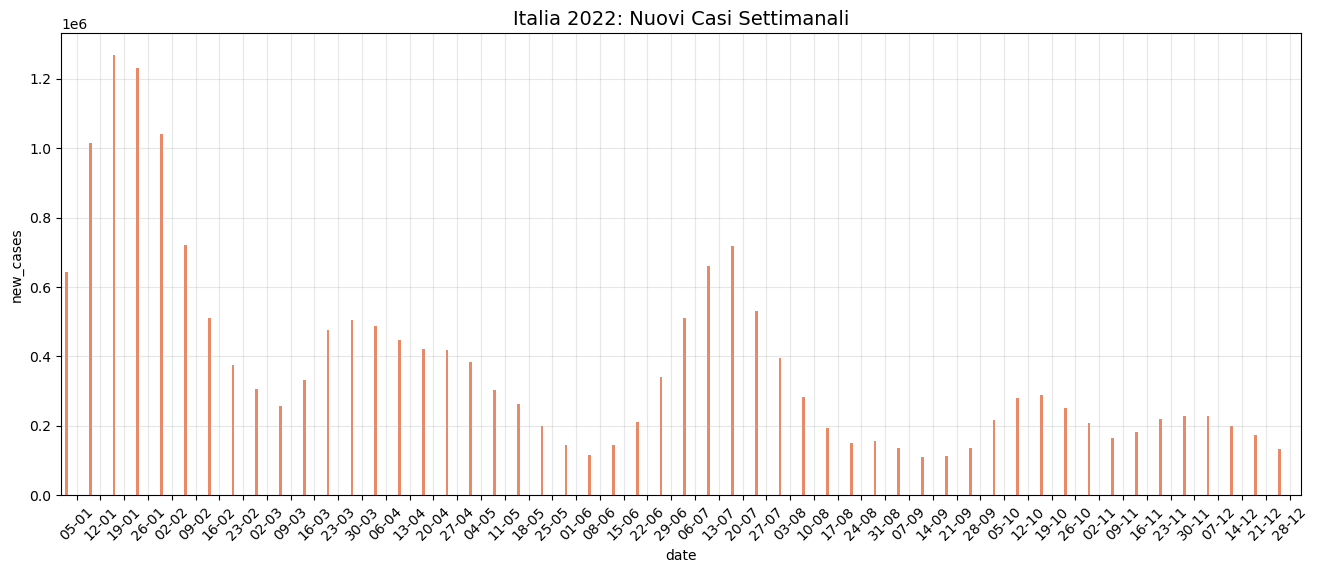

In [25]:
plt.figure(figsize=(16, 6))
# Usiamo barplot: Seaborn colora le barre in base alla data
sns.barplot(data=italy_22, x='date', y='new_cases', color='coral')

# Trucco: siccome le date sono tante, ne mostriamo solo alcune per non sovrapporle
plt.xticks(rotation=45) 
plt.grid(True, alpha=0.3)
plt.title('Italia 2022: Nuovi Casi Settimanali', fontsize=14)
import matplotlib.dates as mdates

 #Mette una tacca ogni lunedì (o ogni 7 giorni)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))

# Scrive la data in formato Giorno/Mese
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
plt.show()

Task 4  Riguardo le nazioni di Italia, Germania e Francia punto
A mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso) e punto
B scrivere un breve commento riguardo a che conclusioni possiamo trarre guardanso il grafico risultante 

In [4]:
print(covid_19['location'].unique())

['Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda'
 'Bhutan' 'Bolivia' 'Bonaire Sint Eustatius and Saba'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Canada' 'Cape Verde' 'Cayman Islands' 'Central African Republic' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Europe' 'European Union (27)' 'Faroe Islands' 'Falkland Islands' 'Fiji'
 'Finland' 'France' 'French Guiana' 'Fr

Risposta Task 4
A)Confronto la distribuzione dei pazienti in terapia intensiva (icu_patients) per Italia, Germania e Francia in un arco di 12 mesi, visualizzando per ogni nazione la media, la variabilità e i picchi (valori anomali). A differenza di una semplice media, il Boxplot mostra l'intera "storia" dei dati: la linea centrale della scatola indica il valore mediano, la grandezza della scatola indica quanto i dati sono stati stabili o altalenanti, e i puntini fuori (outliers) indicano i giorni di emergenza critica.

In [27]:
nazioni_icu=['Germany','Italy','France']
df_icu_periodo =covid_19 [
    (covid_19['location'].isin(nazioni_icu)) & 
    (covid_19['date'] >= '2022-05-01') & 
    (covid_19['date'] <= '2023-04-30')
].copy()
print(df_icu_periodo.groupby('location')['date'].agg(['min', 'max']))

                min        max
location                      
France   2022-05-01 2023-04-30
Germany  2022-05-01 2023-04-30
Italy    2022-05-01 2023-04-30


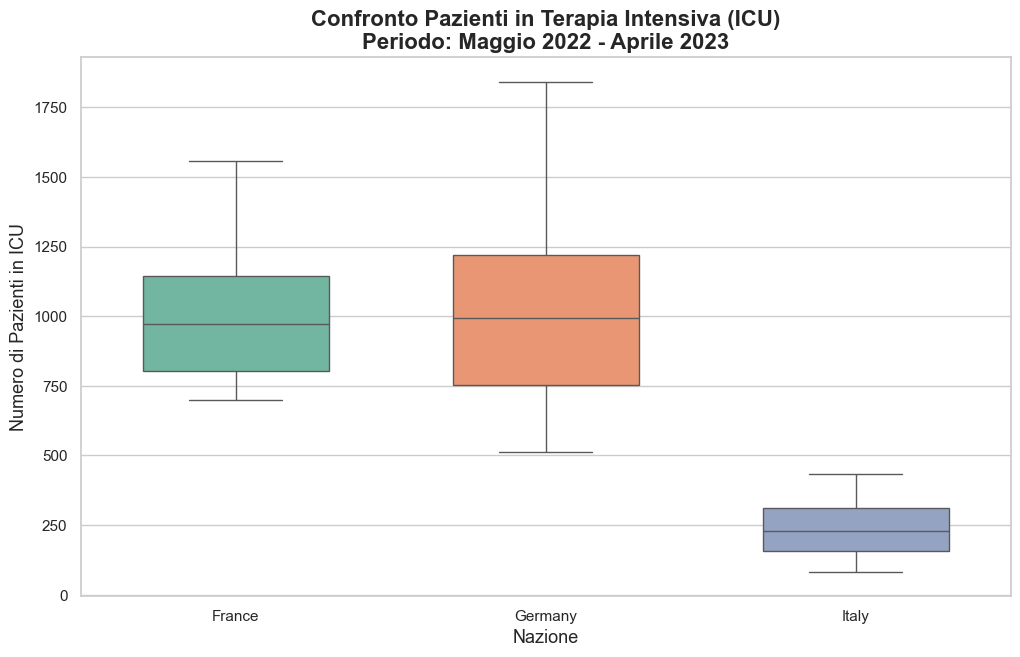

In [28]:
# Impostiamo lo stile di Seaborn per avere una griglia di sfondo pulita
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# Creiamo il Boxplot
# data: la nostra tabella filtrata
# x='location': crea una colonna (una scatola) per ogni nazione
# y='icu_patients': calcola l'altezza della scatola in base ai pazienti ICU
# palette='Set2': sceglie una combinazione di colori gradevole
sns.boxplot(data=df_icu_periodo, x='location', y='icu_patients',hue='location', palette='Set2', width=0.6 , legend=False)

# Aggiungiamo titoli chiari e professionali
plt.title('Confronto Pazienti in Terapia Intensiva (ICU)\nPeriodo: Maggio 2022 - Aprile 2023', fontsize=16, fontweight='bold')
plt.ylabel('Numero di Pazienti in ICU', fontsize=13)
plt.xlabel('Nazione', fontsize=13)

# Rimuoviamo la notazione scientifica sull'asse Y per leggere i numeri interi
plt.ticklabel_format(style='plain', axis='y')

plt.show()

In [ ]:
for nazione in nazioni_icu:
    # Creiamo un sottogruppo solo per quella nazione
    dati_nazione = df_icu_periodo[df_icu_periodo['location'] == nazione]
    
    # Contiamo i nulli e il totale delle righe
    nulli = dati_nazione['icu_patients'].isna().sum()
    totale = len(dati_nazione)
    
    # Calcoliamo la percentuale
    percentuale = (nulli / totale) * 100
    
    # Stampiamo il risultato formattato
    print(f"{nazione}: {nulli} dati mancanti su {totale} ({percentuale:.2f}%)")

risposta TASK4 B
Dall'analisi del boxplot emerge chiaramente che, nel periodo compreso tra Maggio 2022 e Aprile 2023, la Germania ha sostenuto un carico mediano di pazienti in terapia intensiva (ICU) costantemente superiore rispetto a Francia e Italia. La scatola della Germania è anche più estesa verticalmente, indicando una maggiore variabilità e la presenza di ondate più marcate nel corso dell'anno.
I dati della Francia presentano un'assenza di registrazioni per 30 giorni (8.22% del periodo). Questo potrebbe rendere la distribuzione dei pazienti ICU per la Francia leggermente meno precisa rispetto a quella di Italia e Germania

Al contrario, l'Italia presenta la mediana più bassa e una scatola più 'schiacciata', suggerendo una gestione della terapia intensiva più stabile e con numeri mediamente inferiori rispetto alle altre due nazioni europee considerate.

task5
risposta A


In [15]:
nazioni_4 = ['Germany','Italy','France' , 'Spain']
df_nazioni_4 =covid_19 [
(covid_19['location'].isin(nazioni_4)) &
(covid_19['date'].dt.year == 2021)
].copy()

somma_ospedalizzati = df_nazioni_4.groupby('location')['hosp_patients'].sum()
print("Somma totale ospedalizzazioni (giornate-letto) nel 2021:")
print(somma_ospedalizzati)

Somma totale ospedalizzazioni (giornate-letto) nel 2021:
location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


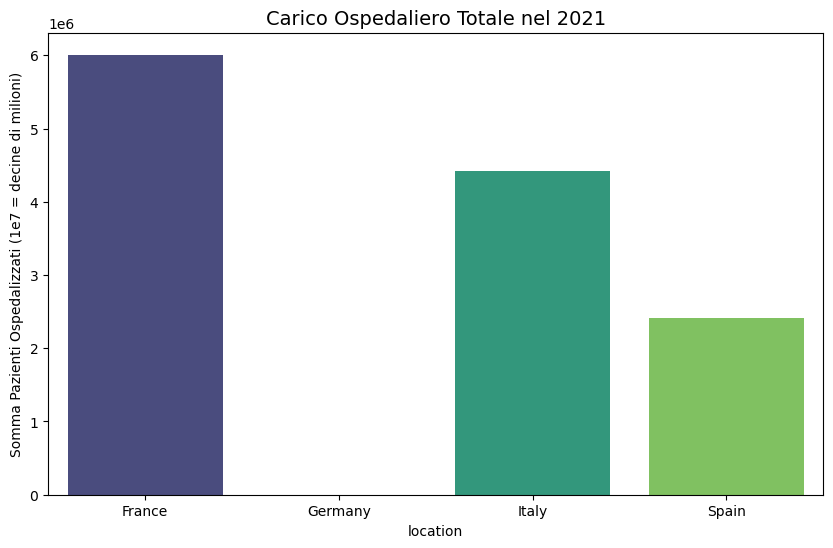

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x=somma_ospedalizzati.index, y=somma_ospedalizzati.values, palette='viridis', hue=somma_ospedalizzati.index, legend=False)
plt.title('Carico Ospedaliero Totale nel 2021', fontsize=14)
plt.ylabel('Somma Pazienti Ospedalizzati (1e7 = decine di milioni)')
plt.show()

In [20]:
germania = ['Germany']
prova = covid_19[
    (covid_19['location'].isin(germania)) & 
    (covid_19['date'].dt.year == 2021)
][['date', 'location', 'hosp_patients']].copy()

# Visualizziamo le prime 20 righe per conferma
print(prova.head(20))

             date location  hosp_patients
140773 2021-01-01  Germany            NaN
140774 2021-01-02  Germany            NaN
140775 2021-01-03  Germany            NaN
140776 2021-01-04  Germany            NaN
140777 2021-01-05  Germany            NaN
140778 2021-01-06  Germany            NaN
140779 2021-01-07  Germany            NaN
140780 2021-01-08  Germany            NaN
140781 2021-01-09  Germany            NaN
140782 2021-01-10  Germany            NaN
140783 2021-01-11  Germany            NaN
140784 2021-01-12  Germany            NaN
140785 2021-01-13  Germany            NaN
140786 2021-01-14  Germany            NaN
140787 2021-01-15  Germany            NaN
140788 2021-01-16  Germany            NaN
140789 2021-01-17  Germany            NaN
140790 2021-01-18  Germany            NaN
140791 2021-01-19  Germany            NaN
140792 2021-01-20  Germany            NaN


risposta task 5B
Dall'analisi dei dati relativi al 2021, emerge che la Germania presenta il 100% di dati mancanti (NaN) per la colonna hosp_patients, mentre la Spagna presenta una parzialità di dati, Nel caso della Germania, poiché il dato è totalmente assente (0.0), la nazione va esclusa dal grafico specifico o segnalata con "Dato non pervenuto" per evitare errori di interpretazione.